In [349]:
import kagglehub
import shutil
import os

# Скачиваем датасет
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

In [350]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV

In [351]:
df = pd.read_csv(os.path.join(path, "vehicles.csv"))

# Обозначения
1. *manufacturer* - производитель (one hot)
2. *fuel* - тип топлива (one hot)
3. *title_status* - юридический статус автомобиля (one hot)
4. *drive* - тип привода (one hot)
5. *size* - размер автомобиля (code feat)
6. *type* - тип автомобиля (one hot)
7. *odometer* - пробег
8. *model* - модель автомобиля (one hot)
9. *state* - штат (one hot)
10. *region* - рынок (one hot)

In [352]:
df.shape

(426880, 26)

In [353]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='str')

## Исследования и работа с выбросами

In [354]:
df_corr = df.corr(numeric_only=True)["price"].sort_values(ascending=False)
df_corr

price       1.000000
odometer    0.010032
lat         0.000357
long       -0.000408
id         -0.002779
year       -0.004925
county           NaN
Name: price, dtype: float64

### `odometer`

<Axes: xlabel='odometer'>

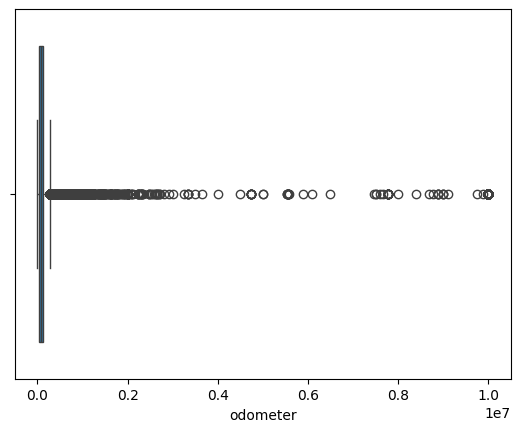

In [355]:
sns.boxplot(data=df, x="odometer")

Лимит: 277300.25
Осталось строк: 418095


<Axes: xlabel='odometer'>

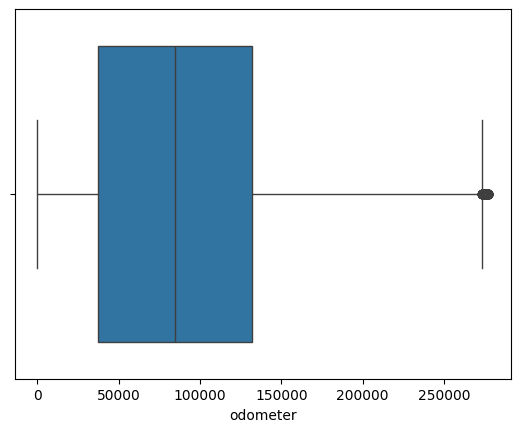

In [356]:
Q1, Q3 = np.nanpercentile(df["odometer"], [25, 75])
IQR = Q3 - Q1
higher_limit = Q3 + 1.5 * IQR

df = df[df["odometer"] < higher_limit]

print(f"Лимит: {higher_limit}")
print(f"Осталось строк: {df.shape[0]}")
sns.boxplot(data=df, x="odometer")


### `year`

<Axes: xlabel='year'>

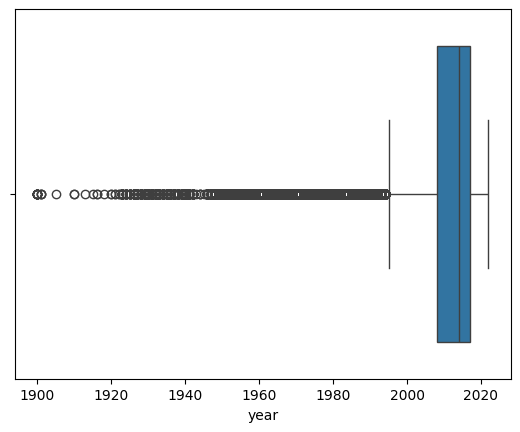

In [357]:
sns.boxplot(data=df, x="year")

In [358]:
Q1, Q3 = np.nanpercentile(df["year"], [25, 75])
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
df = df[df["year"] > lower_limit]

<Axes: xlabel='year'>

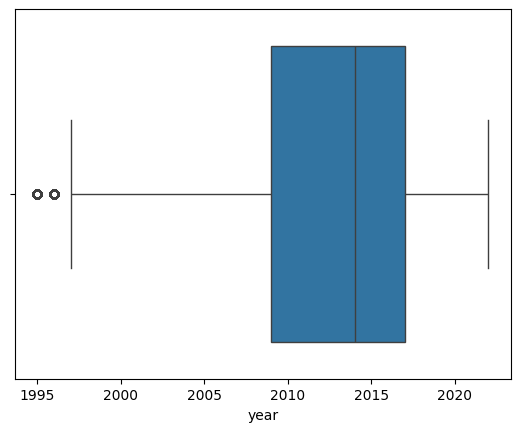

In [359]:
sns.boxplot(data=df, x="year")

### `price`

count    4.017110e+05
mean     6.900708e+04
std      1.215438e+07
min      0.000000e+00
25%      5.995000e+03
50%      1.399900e+04
75%      2.695000e+04
max      3.736929e+09
Name: price, dtype: float64

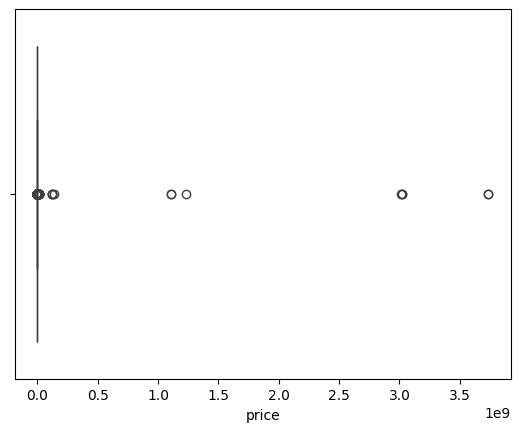

In [360]:
sns.boxplot(data=df, x="price")
df["price"].describe()

In [361]:
print(len(df[(df["price"] < 1000)]))

42635


In [362]:
print(len(df[(df["price"] > 500) & (df["price"] < 1000)]))

2881


In [363]:
print(len(df[(df["price"] > 100000)]))

552


In [364]:
print(len(df[(df["price"] > 100000) & (df["price"] < 125000)]))

251


In [365]:
df = df[(df["price"] > 1000) & (df["price"] < 100000)]

Исследование показывает, что границы в 500 и 125000 долларов являются приемлемыми для чистки от выбросов

<Axes: xlabel='price'>

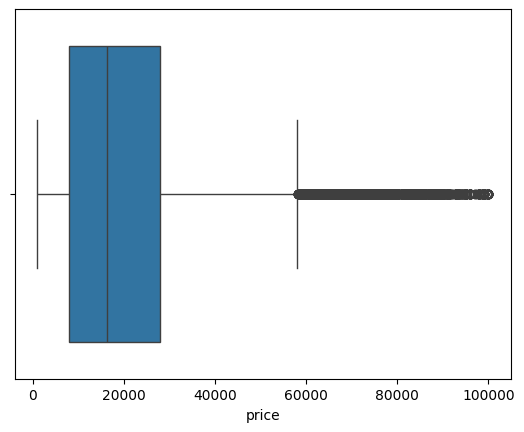

In [366]:
sns.boxplot(data=df, x="price")

In [367]:
state_df = df.dropna(subset=['state']).copy()

state_df['state'] = state_df['state'].str.upper()

grouped_states = state_df.groupby('state')['price'].mean().reset_index()

fig = px.choropleth(
    grouped_states, 
    locations="state",          
    locationmode="USA-states",  
    color="price",              
    scope="usa",                
    color_continuous_scale="Turbo",
    title="Mean price in the USA"
)

fig.update_layout(margin={"r":0, "t":40, "l":0, "b":0})
fig.show()

In [368]:
print(f"Количество строк: {len(df)}")

Количество строк: 357453


In [369]:
pd.to_datetime(df['posting_date'], utc=True).dt.year.unique()

array([2021], dtype=int32)

Наиболее логичным было бы оставить только год публикации объявления, однако все объявления были сделаны в 2021 году, следовательно столбец `posting_date` можно удалить, как и ссылки, широту, долготу и другие.

In [370]:
del_col = ["url", "region_url", "county", "image_url", "lat", "long", "state", "posting_date"]
df = df.drop(del_col, axis=1).set_index("id")

In [371]:
df.corr(numeric_only=True)['price']

price       1.000000
year        0.606788
odometer   -0.558187
Name: price, dtype: float64

Используя знания из предметной области, можно сделать вывод: корреляция выглядит естественно.

### Работа с пропусками

In [372]:
df.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'description'],
      dtype='str')

In [373]:
def found_miss(df):
  percent_na = np.round(100 * df.isna().sum() / len(df), 2)

  return percent_na[percent_na > 0].sort_values()

/var/folders/wn/9_pfkzh96kj2d5yggd7ck6f40000gn/T/ipykernel_5048/3739375903.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");


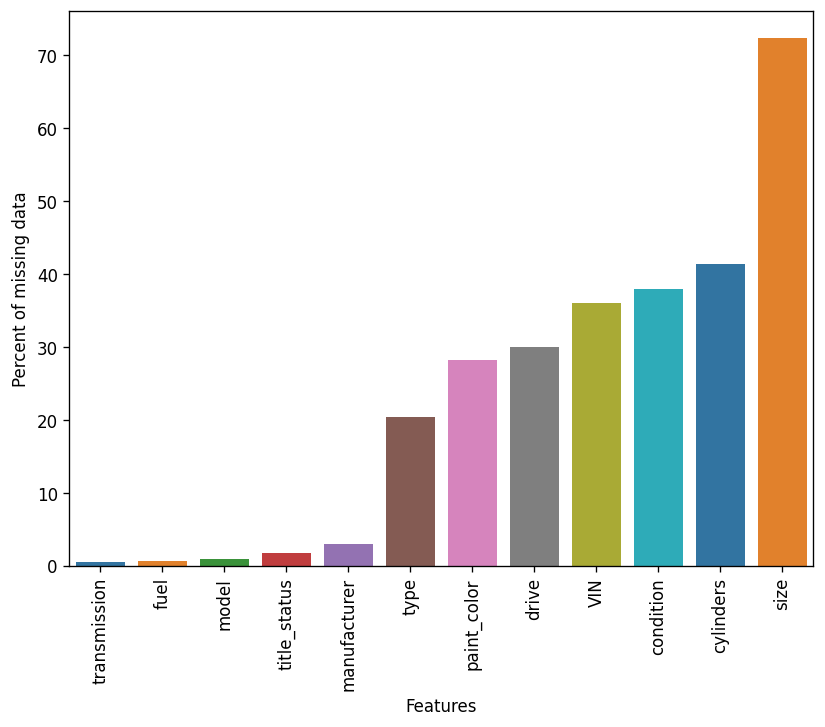

In [374]:
plt.figure(figsize=(8,6), dpi=120);
sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");
plt.xlabel("Features");
plt.ylabel("Percent of missing data");
plt.xticks(rotation=90);
plt.show();

/var/folders/wn/9_pfkzh96kj2d5yggd7ck6f40000gn/T/ipykernel_5048/605149035.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");


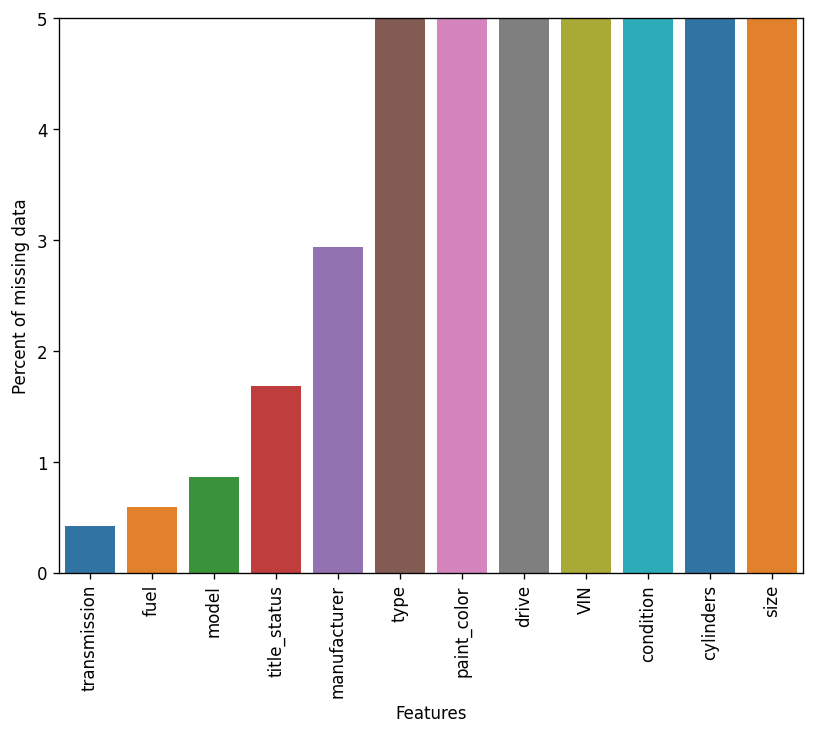

In [375]:
plt.figure(figsize=(8,6), dpi=120);
plt.ylim(0,5)
sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");
plt.xlabel("Features")
plt.ylabel("Percent of missing data")
plt.xticks(rotation=90);
plt.show();

### `transmission`

In [376]:
def fill_mode(x):
    row = x.mode()
    if not row.empty:
        return x.fillna(row[0])
    else:
        return x

In [377]:
print(f"Before:{df["transmission"].isna().sum()}")
df["transmission"] = df.groupby(["manufacturer", "model"], dropna=False)["transmission"].transform(fill_mode)
print(f"After:{df["transmission"].isna().sum()}")
df = df.dropna(subset=["transmission"])

Before:1485
After:64


### `fuel`

In [378]:
print(f"Before:{df["fuel"].isna().sum()}")
df["fuel"] = df.groupby(["manufacturer", "model"], dropna=False)["fuel"].transform(fill_mode)
print(f"After:{df["fuel"].isna().sum()}")
df["fuel"] = df["fuel"].fillna("gas")

Before:2096
After:1395


### `model`

Используя знания из предметной области, делаем вывод: в первых 8-ми числах VIN номера содержится информация о модели автомобиля.

In [379]:
df_copy = df.copy()
df_copy["pattern_vin"] = df["VIN"].str[:8]

In [380]:
df_copy["model"] = df_copy.groupby("pattern_vin", dropna=False)["model"].transform(fill_mode)
print(f"Пропущено: {df_copy["model"].isna().sum()}")
df_copy = df_copy.dropna(subset=["model"])

Пропущено: 193


In [381]:
df_copy["model"] = df_copy["model"].str.lower().str.strip()
freq = df_copy["model"].value_counts()
freq = freq[freq >= 150].index
df_copy["model"] = df_copy["model"].where(df_copy["model"].isin(freq), "other")

In [382]:
df_copy["model"].value_counts()

model
other                       158306
f-150                         8571
silverado 1500                4223
1500                          3684
camry                         2623
                             ...  
fusion sel                     151
fiesta se                      150
pilot ex-l                     150
s5 premium plus sedan 4d       150
q50 3.0t luxe sedan 4d         150
Name: count, Length: 391, dtype: int64

Количество моделей, определённых как "other", слишком велико, к тому же менее распространённые модели содержат лишние символы, поэтому лучше модель определять по первому слову из одноимённой колонки.

In [383]:
df["model"] = df["model"].str.split().str[0].str.lower()

freq = df["model"].value_counts()
good_models = freq[freq >= 150].index

df["model"] = df["model"].where(df["model"].isin(good_models), "other")

df["model"].value_counts()

model
other        34243
silverado    14515
f-150         8457
1500          8051
sierra        7290
             ...  
captiva        157
f              156
rx350          154
cla            152
land           151
Name: count, Length: 308, dtype: int64

### `title_status`

In [384]:
print(df["title_status"].isna().sum())
df["title_status"] = df["title_status"].fillna("Unknown")

5997


### `manufacturer`

In [385]:
print(f"Before:{df["manufacturer"].isna().sum()}")
df["manufacturer"] = df.groupby("model", dropna=False)["manufacturer"].transform(fill_mode)
print(f"After: {df["manufacturer"].isna().sum()}")

Before:10485
After: 2529


In [386]:
df["pattern_vin"] = df["VIN"].str[:8]
print(f"Before:{df["manufacturer"].isna().sum()}")
df["manufacturer"] = df.groupby("pattern_vin", dropna=False)["manufacturer"].transform(fill_mode)
print(f"After: {df["manufacturer"].isna().sum()}")
df = df.dropna(subset=["manufacturer"])

Before:2529
After: 1010


<Axes: xlabel='manufacturer', ylabel='count'>

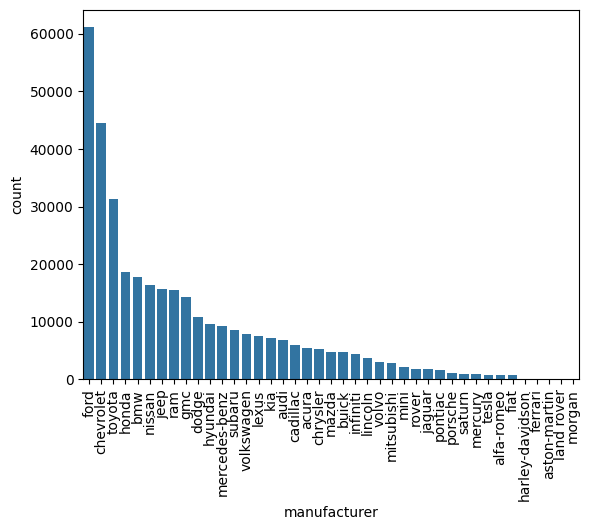

In [387]:
manufacturer_values = df["manufacturer"].value_counts().index
plt.xticks(rotation=90)
sns.countplot(x= df["manufacturer"], order=manufacturer_values)

In [388]:
print(df["manufacturer"].unique())

<StringArray>
[            'gmc',       'chevrolet',          'toyota',            'ford',
            'jeep',          'nissan',             'ram',           'mazda',
        'cadillac',           'honda',           'dodge',           'lexus',
          'jaguar',           'buick',        'chrysler',           'volvo',
            'audi',        'infiniti',         'lincoln',      'alfa-romeo',
          'subaru',           'acura',         'hyundai',   'mercedes-benz',
             'bmw',      'mitsubishi',      'volkswagen',         'porsche',
             'kia',           'rover',         'ferrari',            'mini',
         'pontiac',            'fiat',           'tesla',          'saturn',
         'mercury', 'harley-davidson',    'aston-martin',      'land rover',
          'morgan']
Length: 41, dtype: str


### `size`

In [389]:
df = df.drop("size", axis=1)

### `type`

/var/folders/wn/9_pfkzh96kj2d5yggd7ck6f40000gn/T/ipykernel_5048/2374350663.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df["type"], palette="tab10", order=df["type"].value_counts().index);


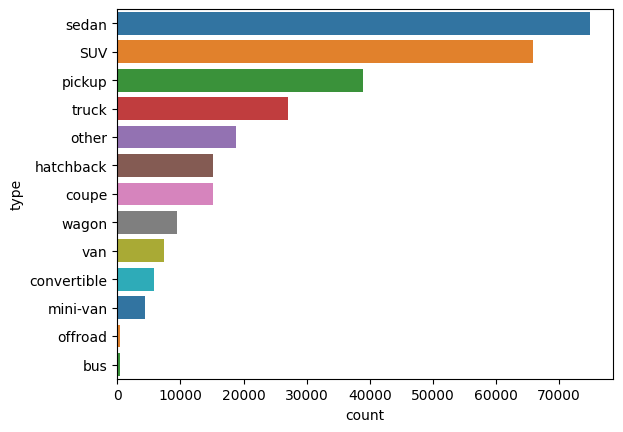

In [390]:
sns.countplot(df["type"], palette="tab10", order=df["type"].value_counts().index);

In [391]:
print(f"Before:{df["type"].isna().sum()}")
df["type"] = df.groupby(["manufacturer", "model"], dropna=False)["type"].transform(fill_mode)
print(f"After manufacturer and model:{df["type"].isna().sum()}")
df["type"] = df.groupby(["model", "drive"], dropna=False)["type"].transform(fill_mode)
print(f"After model and drive:{df["type"].isna().sum()}")
df["type"] = df["type"].fillna(df["type"].mode()[0])

Before:72611
After manufacturer and model:21
After model and drive:0


### `paint_color`

In [392]:
print(f"Before:{df["paint_color"].isna().sum()}")
df["paint_color"] = df["paint_color"].fillna(df["paint_color"].mode()[0])
print(f"After:{df["paint_color"].isna().sum()}")

Before:100537
After:0


### `VIN`

In [393]:
df = df.drop(["VIN", "pattern_vin"], axis=1)

### `drive`

In [394]:
print(f"Before:{df["drive"].isna().sum()}")
df["drive"] = df.groupby(["manufacturer", "model"], dropna=False)["drive"].transform(fill_mode)
print(f"After manufacturer and model:{df["drive"].isna().sum()}")
df["drive"] = df["drive"].fillna(df["drive"].mode()[0])
print(f"After filling with drive:{df["drive"].isna().sum()}")

Before:107000
After manufacturer and model:27
After filling with drive:0


### `condition`

/var/folders/wn/9_pfkzh96kj2d5yggd7ck6f40000gn/T/ipykernel_5048/2136004087.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");


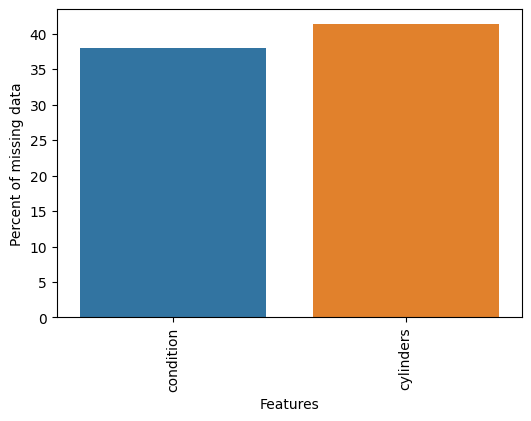

In [395]:
plt.figure(figsize=(6,4), dpi=100);
sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");
plt.xlabel("Features")
plt.ylabel("Percent of missing data")
plt.xticks(rotation=90);
plt.show();

In [396]:
df["condition"].unique()

<StringArray>
['good', 'excellent', 'fair', 'like new', nan, 'new', 'salvage']
Length: 7, dtype: str

In [397]:
bondaries = [0, 6000, 20000, 60000, 100000, 180000, np.inf]
names = ["new", "like new", "excellent", "good", "fair", "salvage"]
odomet_cond = pd.cut(df["odometer"], bins=bondaries, labels=names).astype("str")
df["condition"] = df["condition"].fillna(odomet_cond)

### `cylinders`

In [398]:
df["cylinders"] = df.groupby("model", dropna=False)["cylinders"].transform(fill_mode)
df["cylinders"] = df.groupby("type", dropna=False)["cylinders"].transform(fill_mode)

In [399]:
df["cylinders"] = df["cylinders"].str.split().str[0]
df["cylinders"] = pd.to_numeric(df["cylinders"], errors="coerce")
df["cylinders"] = df["cylinders"].fillna(df["cylinders"].median())

<Axes: xlabel='cylinders'>

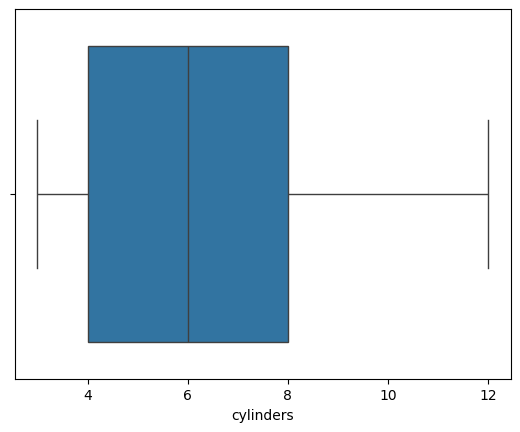

In [400]:
sns.boxplot(data=df, x="cylinders")

In [401]:
df.isna().sum()

region            0
price             0
year              0
manufacturer      0
model             0
condition       269
cylinders         0
fuel              0
odometer          0
title_status      0
transmission      0
drive             0
type              0
paint_color       0
description       2
dtype: int64

In [402]:
df = df.dropna()

<Axes: >

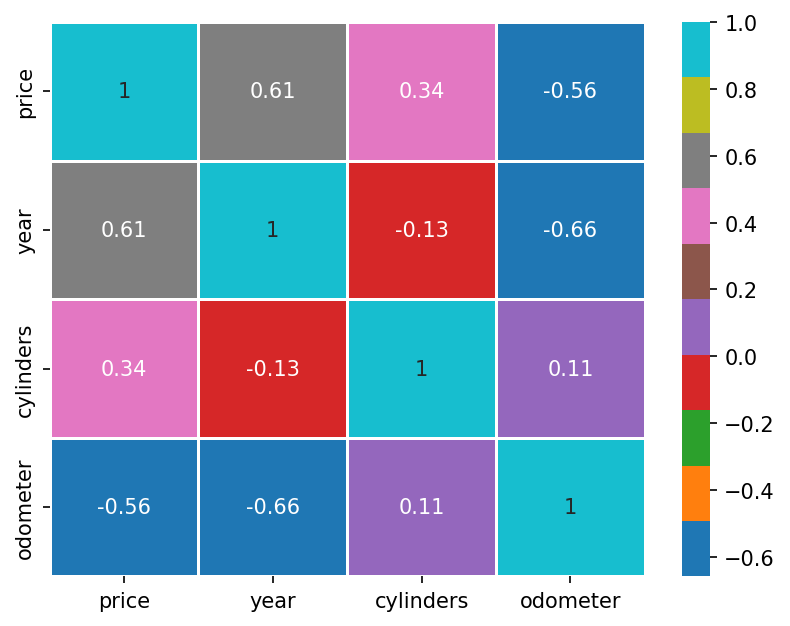

In [403]:
plt.figure(dpi=150)
sns.heatmap(data=df.corr(numeric_only=True), annot=True, lw=0.5, cmap="tab10")

Зависимость между `year` и `odometer` велика (-0.66), из-за чего линейные алгоритмы могут показать низкие результаты.

In [404]:
len(df)

356108

In [405]:
df.columns.tolist()

['region',
 'price',
 'year',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'odometer',
 'title_status',
 'transmission',
 'drive',
 'type',
 'paint_color',
 'description']

Колонки `region`, `manufacturer` и `model` содержат много уникальных значений, поэтому в целях экономии памяти было решено применить **TargetEncoding** после разбиения на тестовую, валидационную и тренировочную выборки. К колонке `description` применим алгоритм **NLP**

In [406]:
print(f"Количество моделей: {len(df["model"].unique())}\nКоличество регионов: {len(df["region"].unique())}\nКоличество марков: {len(df["manufacturer"].unique())}")

Количество моделей: 308
Количество регионов: 404
Количество марков: 41


In [407]:
list_dummies = ["drive", "title_status", "fuel", "condition", "paint_color", "type", "transmission"]
for column in list_dummies:
    df = pd.get_dummies(df, columns=[column], drop_first=True, dtype="int")

In [408]:
len(df.columns)

50

## Supervised Learning

### Подготовка признаков и целевой переменной

In [ ]:

from sklearn.pipeline import Pipeline

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_other, y_train, y_other = train_test_split(X, y, test_size=0.2, random_state=42)

In [411]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=50, stop_words='english')

matrix_train = tfidf.fit_transform(X_train["description"])
matrix_test = tfidf.transform(X_other["description"])

df_matrix_train = pd.DataFrame(matrix_train.toarray(), columns=tfidf.get_feature_names_out(), index=X_train.index)
df_matrix_other = pd.DataFrame(matrix_test.toarray(), columns=tfidf.get_feature_names_out(), index=X_other.index)

X_train = pd.concat([X_train, df_matrix_train], axis=1)
X_other = pd.concat([X_other, df_matrix_other], axis=1)

X_train = X_train.drop("description", axis=1)
X_other = X_other.drop("description", axis=1)

In [412]:
X_valid, X_test, y_valid, y_test = train_test_split(X_other, y_other, test_size=0.5, random_state=42)

In [413]:
from category_encoders import TargetEncoder

encoder = TargetEncoder(cols=['model', 'region', 'manufacturer'])

X_train = encoder.fit_transform(X_train, y_train)

X_valid = encoder.transform(X_valid)

X_test = encoder.transform(X_test)

mean_price = y_valid.mean()

### Linear Regression

In [419]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

lin_pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("linear", LinearRegression(n_jobs=6))
])

lin_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",6


In [420]:
y_pred = lin_pipe.predict(X_valid)

In [421]:
from sklearn.metrics import root_mean_squared_error

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of LR - {RMSE/mean_price*100:.2f}%")

Error of LR - 35.75%


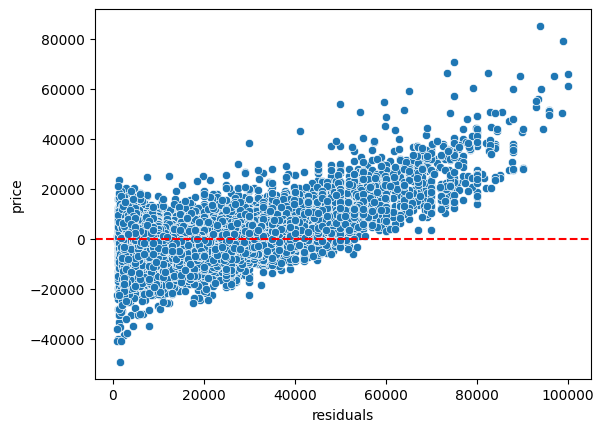

In [422]:
residuals = y_valid - lin_pipe.predict(X_valid)

sns.scatterplot(x=y_valid, y=residuals)
plt.xlabel("residuals")
plt.axhline(y=0, color="red", ls="--")

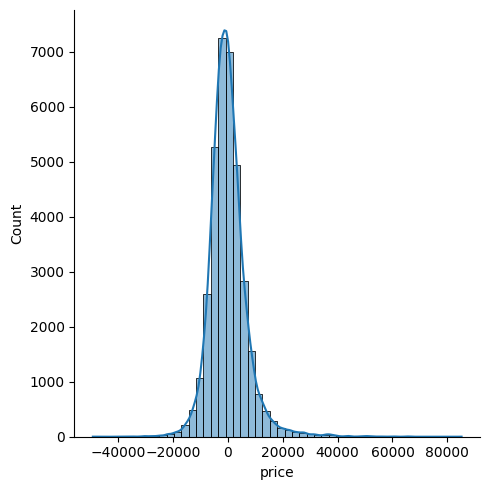

In [423]:
sns.displot(x=residuals, bins=50, kde=True)

### Отчётность по первой модели линейной регрессии

График остатков показывает, что модель линейной регрессии не подходит для датасета, что делает бессмысленным дальнейший подбор гиперпараметров для базовых линейных алгоритмов; также полиномиальная регрессия здесь не допустима ввиду большого количества признаков (253).

Однако возможным решением будет логарифмирование целевой переменной из-за эффекта "расширяющейся воронки". 

In [424]:
y_train_log = np.log1p(y_train)

lin_pipe.fit(X_train, y_train_log)
y_pred = np.expm1(lin_pipe.predict(X_valid))

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of LR: {RMSE/mean_price*100:.2f}%")

Error of LR: 35.49%


Логарифмирование не исправило ситуацию.

### Lasso


Чтобы определить, вызвана ли высокая ошибка модели недообучением или переобучением на большом количестве признаков, была протестирована **Lasso-регуляризация**; данный тип регуляризации был выбран по причине большого количества признаков, а одним из свойством данного типа является обнуление коллинеарных признаков.

In [425]:
from sklearn.linear_model import LassoCV

lasso_pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("lasso_model", LassoCV(cv=10, max_iter=2000, eps=0.0001, n_jobs=6, random_state=42))
])

lasso_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lasso_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.0001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True


In [426]:
y_pred = lasso_pipe.predict(X_valid)

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of Lasso - {RMSE/mean_price*100:.2f}%")

Error of Lasso - 35.75%


### SVM

In [427]:
from sklearn.metrics import get_scorer_names

name_scores = get_scorer_names()
print(name_scores)

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

In [428]:
from sklearn.svm import LinearSVR

SVR_pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("SVR", LinearSVR(dual=False,loss='squared_epsilon_insensitive', random_state=42))
])

param_grid = {
    "SVR__C": [0.01, 0.1, 1, 10],
    "SVR__epsilon": [0.01, 0.1, 0.2],
    "SVR__max_iter": [3000]
}

SVR_grid_model = GridSearchCV(SVR_pipe, param_grid=param_grid, cv=5, verbose=1, scoring="neg_root_mean_squared_error", n_jobs=6)
SVR_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'SVR__C': [0.01, 0.1, ...], 'SVR__epsilon': [0.01, 0.1, ...], 'SVR__max_iter': [3000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",6
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [429]:
y_pred = SVR_grid_model.predict(X_valid)

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of SVR: {RMSE/mean_price*100:.2f}%")

Error of SVR: 35.75%


Точность **LinearSVR** находится на уровне точности базовой линейной регрессии, что окончательно подтверждает отсутствие линейных зависимостей.

**Алгоритм KNN** здесь не применим ввиду размерности.

### Random Forest

In [430]:
from sklearn.ensemble import RandomForestRegressor

RF_pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("RF_model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "RF_model__n_estimators": [100, 150],
    "RF_model__max_features": ["sqrt", "log2"],
    "RF_model__bootstrap": [True],
    "RF_model__max_depth": [10, 15, 20]
}

RF_grid_model = GridSearchCV(RF_pipe, param_grid=param_grid, scoring="neg_root_mean_squared_error", cv=5, verbose=1, n_jobs=6)
RF_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/Users/moymarmois/school 21/Studying/UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V17/herculeh/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'RF_model__bootstrap': [True], 'RF_model__max_depth': [10, 15, ...], 'RF_model__max_features': ['sqrt', 'log2'], 'RF_model__n_estimators': [100, 150]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",6
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >

In [ ]:
y_pred = RF_grid_model.best_estimator_.predict(X_valid)

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of RF: {RMSE/mean_price*100:.2f}%")

Error of RF: 20.01%


In [432]:
RF_grid_model.best_estimator_["RF_model"].get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 20,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 150,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
from supertree import SuperTree

sup_RF_model = RF_grid_model.best_estimator_["RF_model"]

X_RF_train = X_train.sample(n=1000, random_state=42)
y_RF_train = y_train.loc[X_RF_train.index]

super_tree = SuperTree(
    RF_grid_model.best_estimator_["RF_model"], 
    X_RF_train.values,
    y_RF_train.values
)

super_tree.show_tree(0)

**Random Forest** показал хороший результат.

### Gradient Boosting

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

grad_pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("grad_model", HistGradientBoostingRegressor(random_state=42))
])

param_grid = {
    "grad_model__max_iter": [150, 200],
    "grad_model__learning_rate": uniform(0.05, 0.05),
    "grad_model__max_depth": [3, 5, 7]
}

grad_grid_model = RandomizedSearchCV(grad_pipe, param_distributions=param_grid, cv=5, verbose=1, n_jobs=6, scoring="neg_root_mean_squared_error", n_iter=15)
grad_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/Users/moymarmois/school 21/Studying/UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V17/herculeh/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'grad_model__learning_rate': <scipy.stats....t 0x128dc5810>, 'grad_model__max_depth': [3, 5, ...], 'grad_model__max_iter': [150, 200]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",6
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

In [ ]:
y_pred = grad_grid_model.predict(X_valid)

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of Gradient Boosting:{RMSE/mean_price*100:.2f}%")

Error of Gradient Boosting:24.41%


### Отчёт по обучению с учителем

Модель случайного леса показала лучшие результаты, однако стоит заметить, что в градиентном бустинге был использован RandomizedSearchCV, поэтому лучшие параметры могли быть пропущены.

## Unsupervised learning

С помощью кластеризации можно добавить еще колонки признаков, поскольку леса не всегда улавливают скрытые зависимости между признаками.

### K-means

In [433]:
from sklearn.cluster import KMeans

SSD = []
scaler = MinMaxScaler()
X_train_scale = scaler.fit_transform(X_train)
X_valid_scale = scaler.transform(X_valid)
X_all = np.vstack([X_train_scale, X_valid_scale])

for n in range(2,20):
    KM_model = KMeans(n_clusters=n, random_state=42)
    KM_model.fit(X_all)
    SSD.append(KM_model.inertia_)

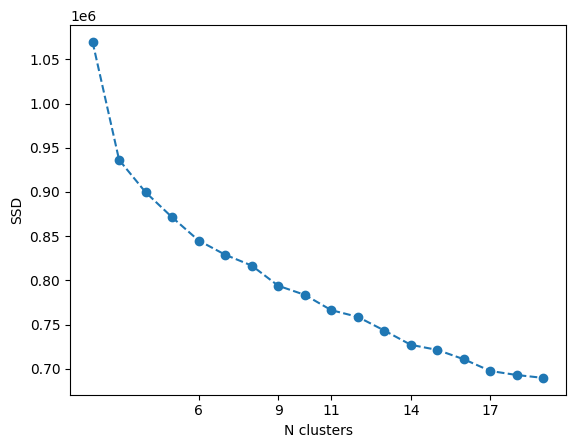

In [440]:
plt.plot(np.arange(2, 20), pd.Series(SSD), "--o")
plt.ylabel("SSD")
plt.xlabel("N clusters")
plt.xticks([6, 9, 11, 14, 17])
plt.show();

По методу локтя трудно определить подходящее число кластеров, однако в качестве основы можно их использовать в методе силуэтов.

In [441]:
from sklearn.metrics import silhouette_score

list_k_cluster = [9, 14, 17]
silhouettes = []

for i in list_k_cluster:
    KM_model = KMeans(n_clusters=i, random_state=42)
    KM_model.fit(X_all)

    silhouettes.append(silhouette_score(X_all, KM_model.labels_, sample_size=100000, random_state=42))

In [442]:
print(silhouettes)

[0.09207424686602284, 0.095734209220732, 0.08566928308502264]


Метод силуэтов показывает низкие результаты, однако в связке с новым признаком новая колонка кластеризации может улучшить результат.

Создаем новую колонку `Cluster`

In [ ]:
KM_model = KMeans(n_clusters=14)

X_train["Cluster"] = KM_model.fit_predict(X_train_scale)
X_valid["Cluster"] = KM_model.predict(X_valid_scale)
X_test["Cluster"] = KM_model.predict(scaler.transform(X_test))

Добавляем признак `Odometer/years`, обозначающий сколько машина в среднем проезжала за год.

In [ ]:
X_train["Odometer/years"] = X_train["odometer"] / (2025 - X_train["year"])
X_valid["Odometer/years"] = X_valid["odometer"] / (2025 - X_valid["year"])
X_test["Odometer/years"] = X_test["odometer"] / (2025 - X_test["year"])

Следующим шагом является изменение гиперпараметров случайного леса и использование **Catboost** заместо **Gradient Boosting**

In [ ]:
param_grid = {
    "RF_model__n_estimators": [150, 200],
    "RF_model__max_features": ["sqrt", "log2"],
    "RF_max_depth": [20, 25, 30],
    "RF_model__bootstrap": [True]
}

RF_grid_model = GridSearchCV(RF_pipe, param_grid=param_grid, scoring="neg_root_mean_squared_error", cv=5, verbose=1, n_jobs=6)
RF_grid_model.fit(X_train, y_train)